### Discharge reconstruction in La Jara

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime
from sklearn.metrics import r2_score
from scipy import stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

# shear stress data
lajara_tau_2022 = pd.read_csv("la_jara/shear_stress_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # Pa
lajara_tau_2023 = pd.read_csv("la_jara/shear_stress_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # Pa

# discharge and precip data 
lajara_2021 = pd.read_csv("la_jara/discharge_2021.csv", parse_dates=[0], index_col=0, na_values=['NaN'])
lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
san_antonio = pd.read_csv("san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", 
                            parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
precipitation = pd.read_csv('san_antonio/airtemp_pcp.csv', parse_dates=[0], index_col=0, na_values=['NaN']) 

# precip data cleanup
precipitation.index = pd.to_datetime(precipitation.index, format='%m/%d/%Y', errors='coerce')
precipitation = precipitation[precipitation.index.notna()]  # remove rows with invalid dates
precipitation = precipitation.replace(-9999, np.nan) # replace -9999 with NaN 

# convert ft^3/s to m3/s for san_antonio, lower_sulphur, and upper_sulphur
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168

# la jara data as base 
lajara_tau_2022.rename(columns={'tau': 'la_jara_tau'}, inplace=True)
lajara_tau_2023.rename(columns={'tau': 'la_jara_tau'}, inplace=True)
lajara_2021.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2022.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'Q': 'la_jara'}, inplace=True)

# remove timezone info from all indices to enable joining
lajara_tau_2022.index = lajara_tau_2022.index.tz_localize(None) if lajara_tau_2022.index.tz is not None else lajara_tau_2022.index
lajara_tau_2023.index = lajara_tau_2023.index.tz_localize(None) if lajara_tau_2023.index.tz is not None else lajara_tau_2023.index
lajara_2022.index = lajara_2022.index.tz_localize(None) if lajara_2022.index.tz is not None else lajara_2022.index
lajara_2023.index = lajara_2023.index.tz_localize(None) if lajara_2023.index.tz is not None else lajara_2023.index
san_antonio.index = san_antonio.index.tz_localize(None) if san_antonio.index.tz is not None else san_antonio.index

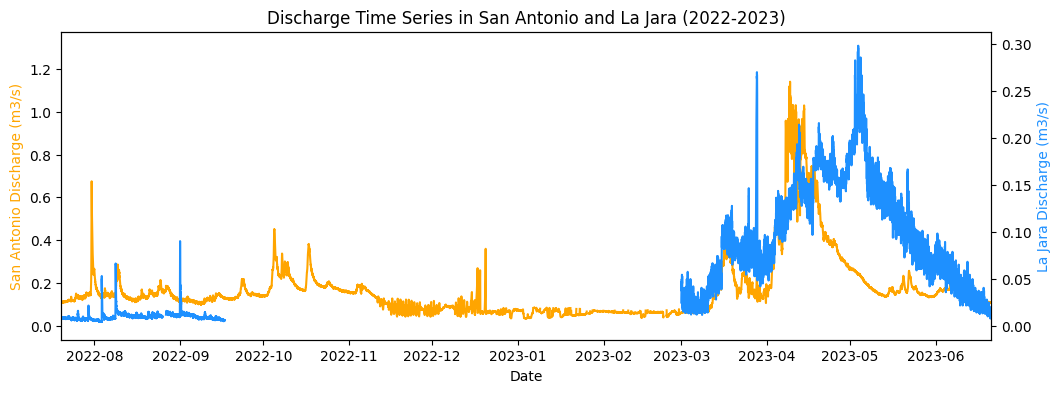

In [5]:
# plot discharge time series for all 4 sites
# 2022
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(san_antonio.index, san_antonio['san_antonio (m3/s)'], label='San Antonio 2022', color='orange')
ax.set_ylabel('San Antonio Discharge (m3/s)', color='orange')

ax2 = ax.twinx()
ax2.plot(lajara_2022.index, lajara_2022['la_jara'], label='La Jara 2022', color='dodgerblue')
ax2.plot(lajara_2023.index, lajara_2023['la_jara'], label='La Jara 2023', color= 'dodgerblue')
ax2.set_ylabel('La Jara Discharge (m3/s)', color='dodgerblue')

ax.set_title('Discharge Time Series in San Antonio and La Jara (2022-2023)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-20'), pd.Timestamp('2023-06-21'))
plt.show()

## Rating Curve

### All years

In [6]:
lajara_2021 = lajara_2021.join(san_antonio['san_antonio (m3/s)'], how='left') 
lajara_2022 = lajara_2022.join(san_antonio['san_antonio (m3/s)'], how='left')
lajara_2023 = lajara_2023.join(san_antonio['san_antonio (m3/s)'], how='left')

lajara_2021 = lajara_2021[(lajara_2021.index >= '2021-08-01')]
lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01')]
lajara_2023 = lajara_2023[(lajara_2023.index >= '2023-08-01')]

merged_all = pd.concat([lajara_2021, lajara_2022, lajara_2023])
print(merged_all.tail())

                      la_jara  san_antonio (m3/s)
2023-09-17 22:45:00  0.005250            0.111950
2023-09-17 23:00:00  0.004656            0.111365
2023-09-17 23:15:00  0.004656            0.112104
2023-09-17 23:30:00  0.005901            0.112550
2023-09-17 23:45:00  0.005250            0.112258


Linear

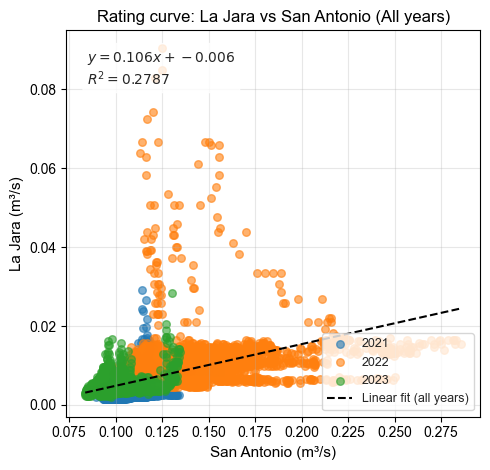

In [7]:
# columns
x_col = 'san_antonio (m3/s)'
y_col = 'la_jara'
valid_data = merged_all[[x_col, y_col]].dropna()

fig, ax = plt.subplots(figsize=(5, 5))
sns.set_style("whitegrid")
# scatter by year
colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}
for year, color in colors.items():
    year_data = valid_data[valid_data.index.year == int(year)]
    ax.scatter(year_data[x_col], year_data[y_col], alpha=0.6, s=30, color=color, label=year)

# fit linear regression to all valid data (the rating curve)
slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data[y_col])
r2 = r_value**2

# regression line
x_line = np.linspace(valid_data[x_col].min(), valid_data[x_col].max(), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, label='Linear fit (all years)')

# labels, legend, annotation
ax.set_xlabel('San Antonio (m³/s)', fontsize=11)
ax.set_ylabel('La Jara (m³/s)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Rating curve: La Jara vs San Antonio (All years)', fontsize=12)
ax.grid(True, alpha=0.3)

# show equation and R^2
eq_text = f'$y = {slope:.3f}x + {intercept:.3f}$\n$R^2 = {r2:.4f}$'
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Logarithmic

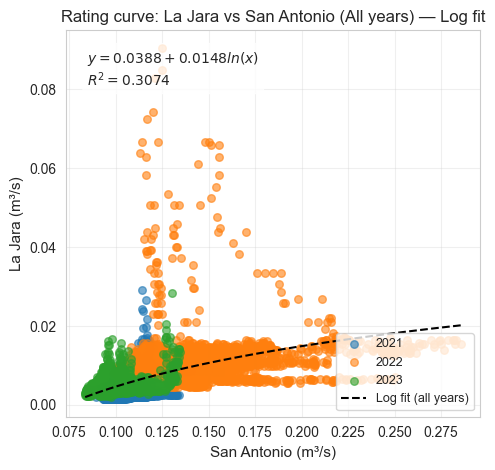

In [8]:
# columns
x_col = 'san_antonio (m3/s)'
y_col = 'la_jara'
valid_data = merged_all[[x_col, y_col]].dropna()

# only positive x-values for log fit
valid_pos = valid_data[valid_data[x_col] > 0].copy()
x = valid_pos[x_col].values
y = valid_pos[y_col].values

def logarithmic(x, a, b):
    return a + b * np.log(x)

fig, ax = plt.subplots(figsize=(5, 5))
sns.set_style("whitegrid")

# scatter by year
colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}
for year, color in colors.items():
    year_data = valid_data[valid_data.index.year == int(year)]
    ax.scatter(year_data[x_col], year_data[y_col], alpha=0.6, s=30, color=color, label=year)

# attempt log fit
if len(x) < 3:
    ax.text(0.05, 0.95, 'Not enough positive data for log fit', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    try:
        popt, pcov = curve_fit(logarithmic, x, y, p0=[0.0, 1.0], maxfev=10000)
        y_pred = logarithmic(x, *popt)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)

        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = logarithmic(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, label='Log fit (all years)')

        eq_text = f'$y = {popt[0]:.4f} + {popt[1]:.4f}ln(x)$\n$R^2 = {r2:.4f}$'
        ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except Exception:
        ax.text(0.05, 0.95, 'Log fit failed', transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# labels, legend, formatting
ax.set_xlabel('San Antonio (m³/s)', fontsize=11)
ax.set_ylabel('La Jara (m³/s)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Rating curve: La Jara vs San Antonio (All years) — Log fit', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Lower Range

Linear

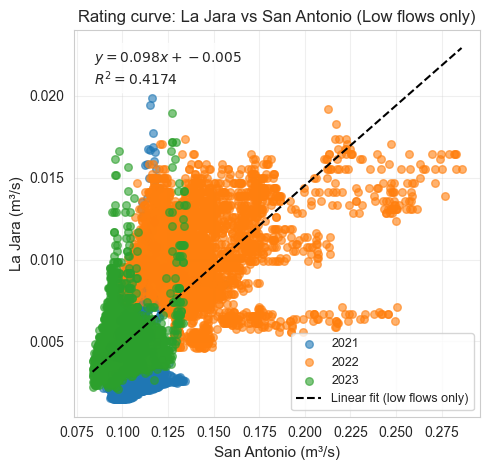

In [9]:
# columns
x_col = 'san_antonio (m3/s)'
y_col = 'la_jara'
valid_data = merged_all[[x_col, y_col]].dropna()
valid_data = valid_data[valid_data['la_jara'] <= 0.02]

fig, ax = plt.subplots(figsize=(5, 5))
sns.set_style("whitegrid")
# scatter by year
colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}
for year, color in colors.items():
    year_data = valid_data[valid_data.index.year == int(year)]
    ax.scatter(year_data[x_col], year_data[y_col], alpha=0.6, s=30, color=color, label=year)

# fit linear regression to all valid data (the rating curve)
slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data[y_col])
r2 = r_value**2

# regression line
x_line = np.linspace(valid_data[x_col].min(), valid_data[x_col].max(), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, label='Linear fit (low flows only)')

# labels, legend, annotation
ax.set_xlabel('San Antonio (m³/s)', fontsize=11)
ax.set_ylabel('La Jara (m³/s)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Rating curve: La Jara vs San Antonio (Low flows only)', fontsize=12)
ax.grid(True, alpha=0.3)

# show equation and R^2
eq_text = f'$y = {slope:.3f}x + {intercept:.3f}$\n$R^2 = {r2:.4f}$'
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Logarithmic

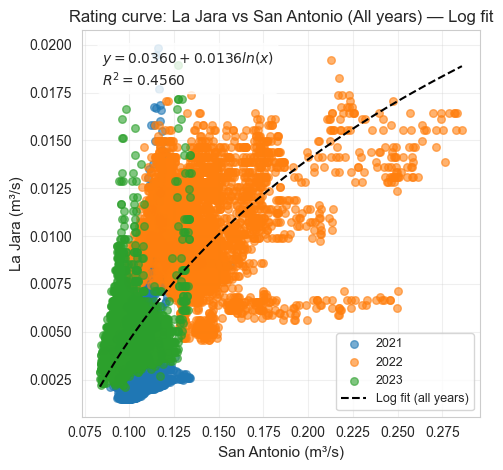

In [10]:
# columns
x_col = 'san_antonio (m3/s)'
y_col = 'la_jara'
valid_data = merged_all[[x_col, y_col]].dropna()
valid_data = valid_data[valid_data['la_jara'] <= 0.02]

# only positive x-values for log fit
valid_pos = valid_data[valid_data[x_col] > 0].copy()
x = valid_pos[x_col].values
y = valid_pos[y_col].values

def logarithmic(x, a, b):
    return a + b * np.log(x)

fig, ax = plt.subplots(figsize=(5, 5))
sns.set_style("whitegrid")

# scatter by year
colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}
for year, color in colors.items():
    year_data = valid_data[valid_data.index.year == int(year)]
    ax.scatter(year_data[x_col], year_data[y_col], alpha=0.6, s=30, color=color, label=year)

# attempt log fit
if len(x) < 3:
    ax.text(0.05, 0.95, 'Not enough positive data for log fit', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    try:
        popt, pcov = curve_fit(logarithmic, x, y, p0=[0.0, 1.0], maxfev=10000)
        y_pred = logarithmic(x, *popt)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)

        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = logarithmic(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, label='Log fit (all years)')

        eq_text = f'$y = {popt[0]:.4f} + {popt[1]:.4f}ln(x)$\n$R^2 = {r2:.4f}$'
        ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except Exception:
        ax.text(0.05, 0.95, 'Log fit failed', transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# labels, legend, formatting
ax.set_xlabel('San Antonio (m³/s)', fontsize=11)
ax.set_ylabel('La Jara (m³/s)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Rating curve: La Jara vs San Antonio (All years) — Log fit', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Reconstructing Discharge

In [11]:
def apply_discontinuity_correction(df, gap_end_date, taper_days, correction_multiplier, 
                                    discharge_col, output_col):
    # find first value after gap
    first_val_after_gap = df[df.index >= gap_end_date][discharge_col].first_valid_index()
    
    if first_val_after_gap is None:
        print("Could not find data after gap")
        df[output_col] = df[discharge_col].copy()
        return df
    
    first_val = df.loc[first_val_after_gap, discharge_col]
    
    # find last value before gap resumes
    last_series = df[df.index < first_val_after_gap][discharge_col]
    last_val = last_series.iloc[-1]
    last_date = last_series.index[-1]
    
    # calculate discontinuity
    discontinuity = first_val - last_val
    correction_amount = discontinuity * correction_multiplier
    
    print(f"Last reconstructed: {last_val:.6f} m³/s on {last_date}")
    print(f"First observed: {first_val:.6f} m³/s on {first_val_after_gap}")
    print(f"Discontinuity: {discontinuity:.6f} m³/s ({discontinuity/first_val*100:.1f}%)")
    print(f"Correction: {correction_amount:.6f} m³/s")
    
    # apply tapering
    df[output_col] = df[discharge_col].copy()
    
    taper_start = last_date - pd.Timedelta(days=taper_days)
    taper_mask = (df.index >= taper_start) & (df.index <= last_date)
    
    taper_subset = df[taper_mask].copy()
    n_taper_points = len(taper_subset)
    
    for i in range(n_taper_points):
        if pd.notna(taper_subset.iloc[i][discharge_col]):
            weight = (i + 1) / n_taper_points
            correction = correction_amount * weight
            taper_subset.iloc[i, taper_subset.columns.get_loc(output_col)] += correction
    
    df.loc[taper_mask, output_col] = taper_subset[output_col]
    
    print(f"\nTaper: {taper_days} days ({taper_start} to {last_date})")
    print(f"Max correction: {correction_amount:.6f} m³/s")
    
    return df

# import data again to adress data gaps 
lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
san_antonio = pd.read_csv("san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", 
                        parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lajara_2022.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'Q': 'la_jara'}, inplace=True)
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
san_antonio.index = san_antonio.index.tz_localize(None) if san_antonio.index.tz is not None else san_antonio.index
san_antonio = san_antonio[(san_antonio.index.year >= 2022) & (san_antonio.index.year <= 2023)]

lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01')]
san_antonio = san_antonio[(san_antonio.index >= '2022-08-01')]

In [12]:
lajara_full = pd.concat([lajara_2022, lajara_2023]).sort_index()
# create continuous date range
date_range = pd.date_range(start=lajara_full.index.min(), end=lajara_full.index.max(), freq='15min')

lajara_sanantonio = lajara_full.join(san_antonio['san_antonio (m3/s)'], how='outer')
lajara_sanantonio.rename(columns={'la_jara': 'la_jara_observed'}, inplace=True)
# remove duplicate indices
lajara_sanantonio = lajara_sanantonio[~lajara_sanantonio.index.duplicated(keep='first')]

# Now check gaps
print("Data gaps in La Jara discharge:")
gap_mask = lajara_sanantonio['la_jara_observed'].isna()
gap_dates = lajara_sanantonio.index[gap_mask]
print(f"Total gap entries: {len(gap_dates)}")

Data gaps in La Jara discharge:
Total gap entries: 12311


Apply rating curve 

In [13]:
# calculate discharge using rating curve
#lajara_sanantonio['estimated_Q'] = 0.0360 + 0.0136 * np.log(lajara_sanantonio['san_antonio (m3/s)'])  # logarithmic
lajara_sanantonio['estimated_Q'] = 0.098 * lajara_sanantonio['san_antonio (m3/s)'] + -0.005  # linear

# overwrite entire window with San Antonio estimate
lajara_sanantonio.loc[gap_mask, 'la_jara_observed'] = lajara_sanantonio.loc[gap_mask, 'estimated_Q']

In [14]:
lajara_sanantonio

,la_jara_observed,san_antonio (m3/s),estimated_Q
2022-08-01 00:00:00,0.007120,0.250340,0.019533
2022-08-01 00:15:00,0.006257,0.249357,0.019437
2022-08-01 00:30:00,0.006677,0.245818,0.019090
2022-08-01 00:45:00,0.006677,0.245451,0.019054
2022-08-01 01:00:00,0.006677,0.241461,0.018663
...,...,...,...
2023-10-12 11:45:00,0.007049,0.122947,0.007049
2023-10-12 12:00:00,0.006965,0.122092,0.006965
2023-10-12 12:15:00,0.007226,0.124758,0.007226
2023-10-12 12:30:00,0.007103,0.123504,0.007103


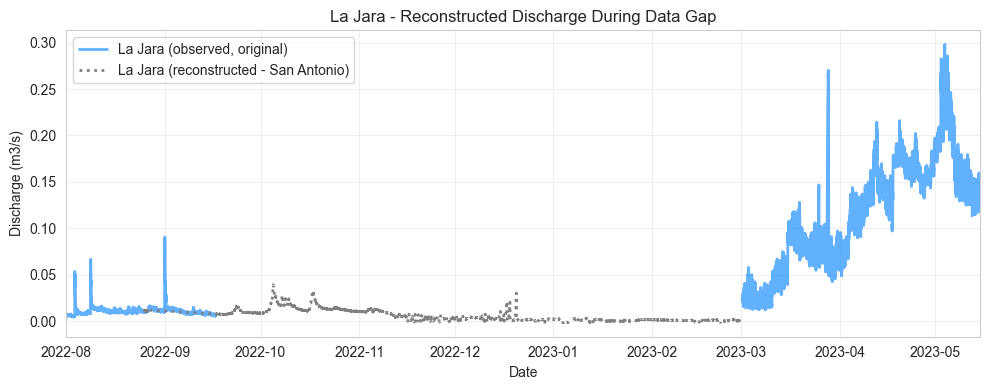

In [15]:
gap_start = pd.Timestamp('2022-09-17')
cutoff = pd.Timestamp('2023-03-01 12:00')

fig = plt.figure(figsize=(10, 4))
# plot pre-gap original data
before_gap = lajara_sanantonio.index < gap_start
plt.plot(lajara_sanantonio.index[before_gap], lajara_sanantonio.loc[before_gap, 'la_jara_observed'],
    label='La Jara (observed, original)', color='dodgerblue', linewidth=2, alpha=0.7)
# plot post-gap original data
after_gap = lajara_sanantonio.index > cutoff
plt.plot(lajara_sanantonio.index[after_gap], lajara_sanantonio.loc[after_gap, 'la_jara_observed'],
    color='dodgerblue', linewidth=2, alpha=0.7)

# plot overwritten reconstruction window (San Antonio)
# interpolate to handle sparse data with NaN gaps
reconstructed = lajara_sanantonio[gap_mask].copy()
reconstructed['la_jara_interp'] = reconstructed['estimated_Q'].interpolate(method='linear')

plt.plot(reconstructed.index, reconstructed['estimated_Q'], label='La Jara (reconstructed - San Antonio)',
    color='gray', linestyle=':',linewidth=2)

plt.xlabel('Date')
plt.ylabel('Discharge (m3/s)')
plt.title('La Jara - Reconstructed Discharge During Data Gap')
plt.legend(loc='upper left')
plt.xlim(pd.Timestamp('2022-08-01'), pd.Timestamp('2023-05-15'))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Tapering for discontinuity

In [16]:
# create a combined filled version
lajara_sanantonio['la_jara_filled'] = lajara_sanantonio['la_jara_observed'].copy()
lajara_sanantonio.loc[gap_mask, 'la_jara_filled'] = lajara_sanantonio.loc[gap_mask, 'estimated_Q']
gap_start = pd.Timestamp('2022-09-17')
cutoff = pd.Timestamp('2023-03-01')

# apply discontinuity correction to the filled version
lajara_sanantonio = apply_discontinuity_correction(
    df=lajara_sanantonio,
    gap_end_date=cutoff,
    taper_days=50,  
    correction_multiplier=0.3,
    discharge_col='la_jara_filled',
    output_col='la_jara_corrected'
)

Last reconstructed: 0.000805 m³/s on 2023-02-28 23:30:00
First observed: 0.025262 m³/s on 2023-03-01 00:00:00
Discontinuity: 0.024458 m³/s (96.8%)
Correction: 0.007337 m³/s

Taper: 50 days (2023-01-09 23:30:00 to 2023-02-28 23:30:00)
Max correction: 0.007337 m³/s


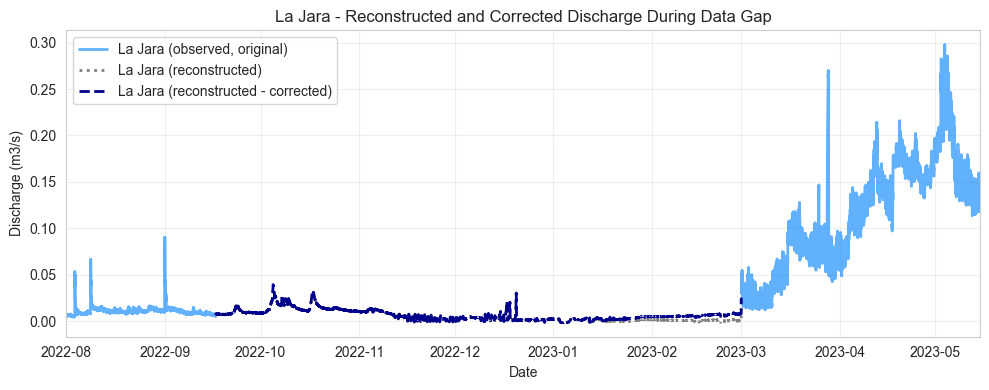

In [17]:
fig = plt.figure(figsize=(10, 4))
# plot pre-gap original data
before_gap = lajara_sanantonio.index < gap_start
plt.plot(lajara_sanantonio.index[before_gap], lajara_sanantonio.loc[before_gap, 'la_jara_observed'],
    label='La Jara (observed, original)', color='dodgerblue', linewidth=2, alpha=0.7)
# plot post-gap original data
after_gap = lajara_sanantonio.index > cutoff
plt.plot(lajara_sanantonio.index[after_gap], lajara_sanantonio.loc[after_gap, 'la_jara_observed'],
    color='dodgerblue', linewidth=2, alpha=0.7)

# plot reconstructed discharge during gap
gap_period = (lajara_sanantonio.index >= gap_start) & (lajara_sanantonio.index <= cutoff)
plt.plot(lajara_sanantonio.index[gap_period], lajara_sanantonio.loc[gap_period, 'la_jara_filled'], 
    label='La Jara (reconstructed)', color='gray', linestyle=':', linewidth=2)

# plot bias-corrected reconstructed discharge
plt.plot(lajara_sanantonio.index[gap_period], lajara_sanantonio.loc[gap_period, 'la_jara_corrected'], 
    label='La Jara (reconstructed - corrected)', color='darkblue', linestyle='--', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Discharge (m3/s)')
plt.title('La Jara - Reconstructed and Corrected Discharge During Data Gap')
plt.legend(loc='upper left')
plt.xlim(pd.Timestamp('2022-08-01'), pd.Timestamp('2023-05-15'))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Smooth Nov-Feb ice noise
This smooths only the likely ice-affected period (Nov-Feb) and keeps all other dates unchanged.

Method:
1. Time interpolation inside the target period
2. Median smoother (robust to spikes)
3. Mean smoother (gentle final smoothing)

In [18]:
# smooth only the likely ice-affected period (Nov-Feb)
ice_start = pd.Timestamp('2022-11-01')
ice_end = pd.Timestamp('2023-03-01')

# choose source series (prefer corrected reconstruction if present)
if 'la_jara_corrected' in lajara_sanantonio.columns:
    source_col = 'la_jara_corrected'
elif 'la_jara_filled' in lajara_sanantonio.columns:
    source_col = 'la_jara_filled'
else:
    source_col = 'la_jara_observed'

print(f"Using source column: {source_col}")

# start with full copy
la_jara_smoothed = lajara_sanantonio[source_col].copy()

# define ice-affected period
ice_mask = (lajara_sanantonio.index >= ice_start) & (lajara_sanantonio.index <= ice_end)

# work only inside Nov-Feb window
segment = la_jara_smoothed.loc[ice_mask].copy()

# fill short gaps for stable smoothing
segment_interp = segment.interpolate(method='time', limit_direction='both')

# robust two-stage smoothing:
# 1) median filter removes spikes
# 2) mean filter softens residual jitter
segment_smooth = (
    segment_interp
    .rolling('10h', center=True, min_periods=1).median()
    .rolling('20h', center=True, min_periods=1).mean()
)

# replace only Nov-Feb values
la_jara_smoothed.loc[ice_mask] = segment_smooth

# add to dataframe
lajara_sanantonio['la_jara_smoothed_ice'] = la_jara_smoothed

print(f"\nSmoothed period: {ice_start.date()} to {ice_end.date()}")
print(f"Input column: {source_col}")
print(f"Output column: la_jara_smoothed_ice")
print(f"Rows smoothed: {ice_mask.sum()}")

Using source column: la_jara_corrected

Smoothed period: 2022-11-01 to 2023-03-01
Input column: la_jara_corrected
Output column: la_jara_smoothed_ice
Rows smoothed: 5514


Plotting source: la_jara_corrected


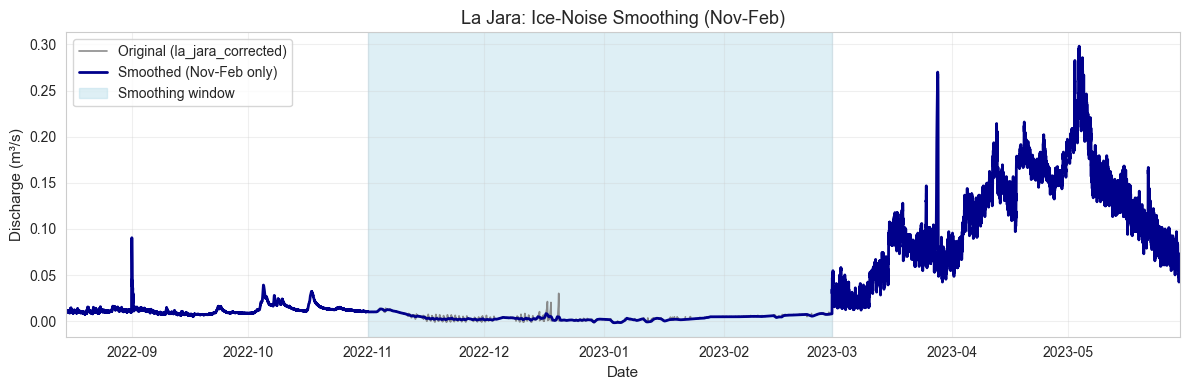

In [19]:
# use same source column logic for consistency
if 'la_jara_corrected' in lajara_sanantonio.columns:
    plot_source_col = 'la_jara_corrected'
elif 'la_jara_filled' in lajara_sanantonio.columns:
    plot_source_col = 'la_jara_filled'
else:
    plot_source_col = 'la_jara_observed'

print(f"Plotting source: {plot_source_col}")

# time window for visualization
plot_start = pd.Timestamp('2022-08-15')
plot_end = pd.Timestamp('2023-05-30')
plot_mask = (lajara_sanantonio.index >= plot_start) & (lajara_sanantonio.index <= plot_end)

# create figure and plot
fig, ax = plt.subplots(figsize=(12, 4))

# original (with all noise)
ax.plot(
    lajara_sanantonio.index[plot_mask],
    lajara_sanantonio.loc[plot_mask, plot_source_col],
    label=f'Original ({plot_source_col})',
    color='gray',
    linewidth=1.2,
    alpha=0.9,
    zorder=1
)

# smoothed version (Nov-Feb only)
ax.plot(
    lajara_sanantonio.index[plot_mask],
    lajara_sanantonio.loc[plot_mask, 'la_jara_smoothed_ice'],
    label='Smoothed (Nov-Feb only)',
    color='darkblue',
    linewidth=2.0,
    zorder=2
)

# highlight the smoothing window
ax.axvspan(ice_start, ice_end, color='lightblue', alpha=0.4, label='Smoothing window', zorder=0)

# formatting
ax.set_title('La Jara: Ice-Noise Smoothing (Nov-Feb)', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(plot_start, plot_end)

plt.tight_layout()
plt.show()

In [20]:
# second smoothing round: January to mid-March (spring rising limb)
# input: ice-smoothed data (la_jara_smoothed_ice)
# goal: lighter smoothing on spring rising limb to preserve flow increase

spring_start = pd.Timestamp('2023-02-26')
spring_end = pd.Timestamp('2023-03-10')

print(f"Starting second smoothing round...")
print(f"Input: la_jara_smoothed_ice")
print(f"Target period: {spring_start.date()} to {spring_end.date()}")

# start with ice-smoothed data
la_jara_smoothed_both = lajara_sanantonio['la_jara_smoothed_ice'].copy()
# define spring window
spring_mask = (lajara_sanantonio.index >= spring_start) & (lajara_sanantonio.index <= spring_end)
# extract spring segment
segment_spring = la_jara_smoothed_both.loc[spring_mask].copy()
# fill short gaps
segment_spring_interp = segment_spring.interpolate(method='time', limit_direction='both')
segment_spring_smooth = (
    segment_spring_interp
    .rolling('10h', center=True, min_periods=1).median()
    .rolling('12h', center=True, min_periods=1).mean()
)

# replace only Jan-Mar values
la_jara_smoothed_both.loc[spring_mask] = segment_spring_smooth
# add to dataframe
lajara_sanantonio['la_jara_smoothed_spring'] = la_jara_smoothed_both


Starting second smoothing round...
Input: la_jara_smoothed_ice
Target period: 2023-02-26 to 2023-03-10


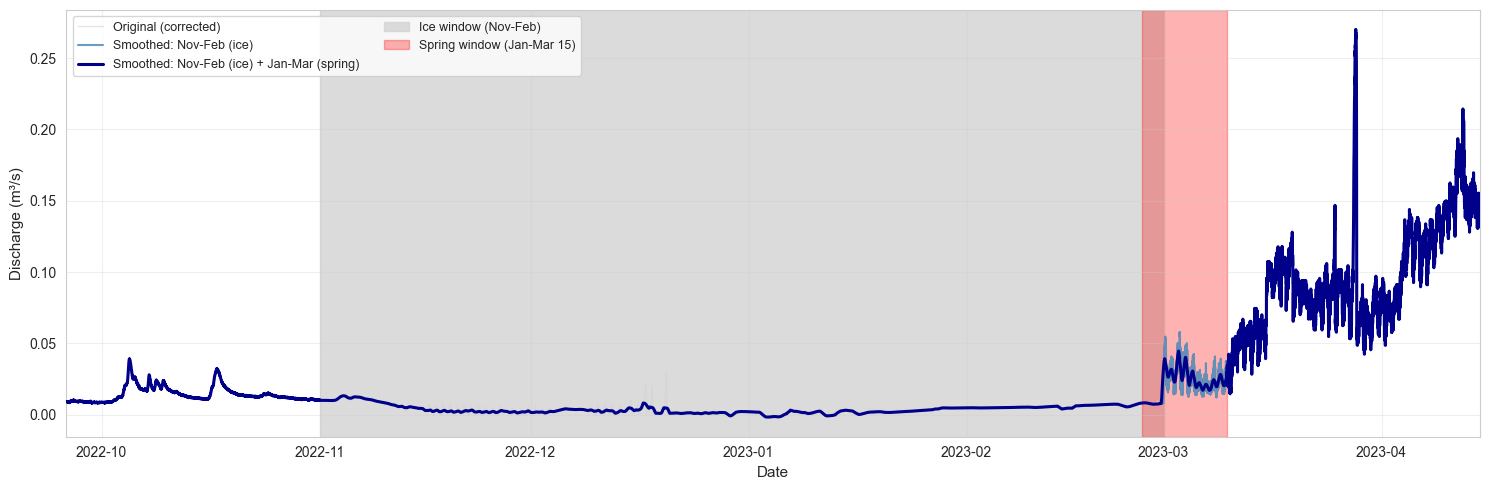

In [21]:
# three-way comparison: Original → Ice smoothed → Spring smoothed
fig, ax = plt.subplots(figsize=(15, 5))

# plot window
comp_start = pd.Timestamp('2022-09-26')
comp_end = pd.Timestamp('2023-04-15')
comp_mask = (lajara_sanantonio.index >= comp_start) & (lajara_sanantonio.index <= comp_end)

# layer 1: original corrected (base)
ax.plot(
    lajara_sanantonio.index[comp_mask],
    lajara_sanantonio.loc[comp_mask, 'la_jara_corrected'],
    label='Original (corrected)',
    color='lightgray',
    linewidth=1.0,
    alpha=0.6,
    zorder=1
)

# layer 2: ice smoothed
ax.plot(
    lajara_sanantonio.index[comp_mask],
    lajara_sanantonio.loc[comp_mask, 'la_jara_smoothed_ice'],
    label='Smoothed: Nov-Feb (ice)',
    color='steelblue',
    linewidth=1.5,
    alpha=0.8,
    zorder=2
)

# layer 3: ice + spring smoothed (final)
ax.plot(
    lajara_sanantonio.index[comp_mask],
    lajara_sanantonio.loc[comp_mask, 'la_jara_smoothed_spring'],
    label='Smoothed: Nov-Feb (ice) + Jan-Mar (spring)',
    color='darkblue',
    linewidth=2.2,
    zorder=3
)

# highlight smoothing windows
ax.axvspan(ice_start, ice_end, color='lightgray', alpha=0.8, label='Ice window (Nov-Feb)', zorder=0)
ax.axvspan(spring_start, spring_end, color='red', alpha=0.3, label='Spring window (Jan-Mar 15)', zorder=0)

# formatting
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_xlim(comp_start, comp_end)

plt.tight_layout()
plt.show()


In [22]:
# second smoothing round: January to mid-March (spring rising limb)
# input: ice-smoothed data (la_jara_smoothed_ice)
# goal: lighter smoothing on spring rising limb to preserve flow increase

spring_start = pd.Timestamp('2023-02-28')
spring_end = pd.Timestamp('2023-07-27')

print(f"Starting second smoothing round...")
print(f"Input: la_jara_smoothed_spring")
print(f"Target period: {spring_start.date()} to {spring_end.date()}")

# start with ice-smoothed data
la_jara_smoothed_both = lajara_sanantonio['la_jara_smoothed_spring'].copy()
# define spring window
spring_mask = (lajara_sanantonio.index >= spring_start) & (lajara_sanantonio.index <= spring_end)
# extract spring segment
segment_spring = la_jara_smoothed_both.loc[spring_mask].copy()
# fill short gaps
segment_spring_interp = segment_spring.interpolate(method='time', limit_direction='both')
segment_spring_smooth = (
    segment_spring_interp
    .rolling('0.1h', center=True, min_periods=1).median()
    .rolling('0.01h', center=True, min_periods=1).mean()
)

# replace only Jan-Mar values
la_jara_smoothed_both.loc[spring_mask] = segment_spring_smooth
# add to dataframe
lajara_sanantonio['la_jara_smoothed_spring'] = la_jara_smoothed_both

Starting second smoothing round...
Input: la_jara_smoothed_spring
Target period: 2023-02-28 to 2023-07-27


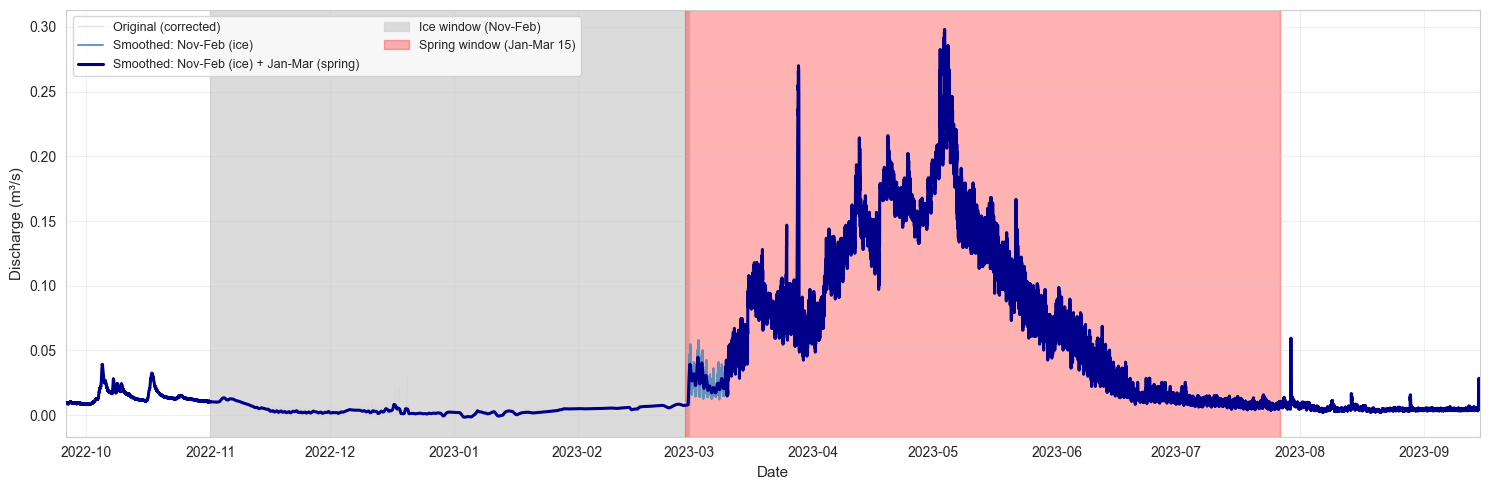

In [23]:
# three-way comparison: Original → Ice smoothed → Spring smoothed
fig, ax = plt.subplots(figsize=(15, 5))

# plot window
comp_start = pd.Timestamp('2022-09-26')
comp_end = pd.Timestamp('2023-09-15')
comp_mask = (lajara_sanantonio.index >= comp_start) & (lajara_sanantonio.index <= comp_end)

# layer 1: original corrected (base)
ax.plot(
    lajara_sanantonio.index[comp_mask],
    lajara_sanantonio.loc[comp_mask, 'la_jara_corrected'],
    label='Original (corrected)',
    color='lightgray',
    linewidth=1.0,
    alpha=0.6,
    zorder=1
)

# layer 2: ice smoothed
ax.plot(
    lajara_sanantonio.index[comp_mask],
    lajara_sanantonio.loc[comp_mask, 'la_jara_smoothed_ice'],
    label='Smoothed: Nov-Feb (ice)',
    color='steelblue',
    linewidth=1.5,
    alpha=0.8,
    zorder=2
)

# layer 3: ice + spring smoothed (final)
ax.plot(
    lajara_sanantonio.index[comp_mask],
    lajara_sanantonio.loc[comp_mask, 'la_jara_smoothed_spring'],
    label='Smoothed: Nov-Feb (ice) + Jan-Mar (spring)',
    color='darkblue',
    linewidth=2.2,
    zorder=3
)

# highlight smoothing windows
ax.axvspan(ice_start, ice_end, color='lightgray', alpha=0.8, label='Ice window (Nov-Feb)', zorder=0)
ax.axvspan(spring_start, spring_end, color='red', alpha=0.3, label='Spring window (Jan-Mar 15)', zorder=0)

# formatting
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_xlim(comp_start, comp_end)

plt.tight_layout()
plt.show()

## Plot reconstructed discharge

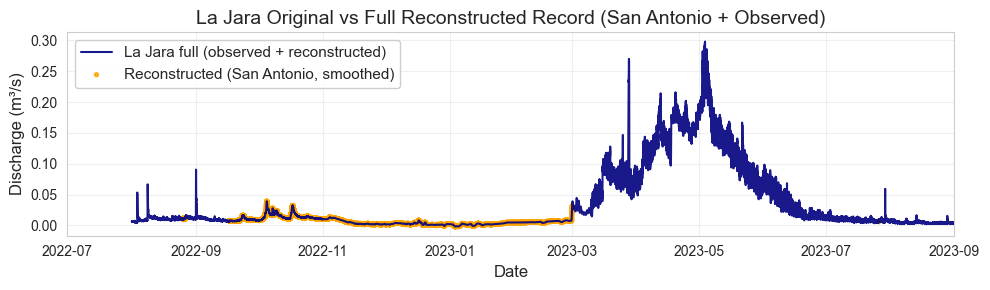

In [24]:
lajara_full_record = lajara_sanantonio['la_jara_smoothed_spring'].copy()

full_start = pd.Timestamp('2022-07-01')
full_end = pd.Timestamp('2023-09-01')
full_mask = (lajara_sanantonio.index >= full_start) & (lajara_sanantonio.index <= full_end)

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(
    lajara_sanantonio.index[full_mask],
    lajara_full_record[full_mask],
    label='La Jara full (observed + reconstructed)',
    color='navy',
    linewidth=1.5,
    zorder=3,
    alpha=0.9
)

reconstructed_mask = full_mask & gap_mask
ax.scatter(
    lajara_sanantonio.index[reconstructed_mask],
    lajara_full_record[reconstructed_mask],
    label='Reconstructed (San Antonio, smoothed)',
    color='orange',
    s=15,
    alpha=0.9,
    zorder=2,
    edgecolors='none'
)

ax.set_title('La Jara Original vs Full Reconstructed Record (San Antonio + Observed)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.grid(True, alpha=0.3, zorder=1)
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.set_xlim(full_start, full_end)

plt.tight_layout()
plt.show()


Plot comparison with precipitation

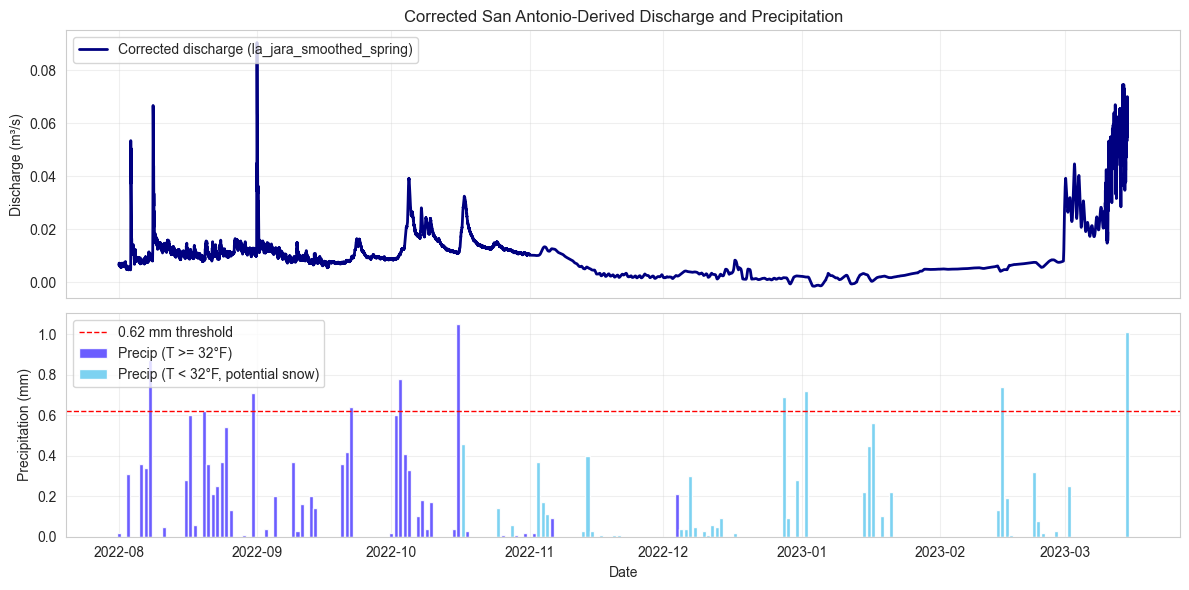

In [25]:
# helper to find likely columns
def find_column(df, keywords):
    for col in df.columns:
        name = col.lower()
        if any(keyword in name for keyword in keywords):
            return col
    return None

# plot window
plot_start = pd.Timestamp('2022-08-01')
plot_end = pd.Timestamp('2023-03-15')

# use the corrected reconstructed La Jara series derived from San Antonio
if 'la_jara_smoothed_spring' in lajara_sanantonio.columns:
    discharge_col = 'la_jara_smoothed_spring'
elif 'la_jara_smoothed_ice' in lajara_sanantonio.columns:
    discharge_col = 'la_jara_smoothed_ice'
elif 'la_jara_corrected' in lajara_sanantonio.columns:
    discharge_col = 'la_jara_corrected'
elif 'la_jara_filled' in lajara_sanantonio.columns:
    discharge_col = 'la_jara_filled'
else:
    discharge_col = 'la_jara_observed'

# discharge series to plot
sa = lajara_sanantonio.loc[(lajara_sanantonio.index >= plot_start) & (lajara_sanantonio.index <= plot_end), discharge_col].copy()
sa = sa.to_frame(name='corrected_discharge')

# precipitation data
precip = precipitation.copy()
precip = precip.loc[(precip.index >= plot_start) & (precip.index <= plot_end)]
precip_col = find_column(precip, ['precip', 'prcp', 'ppt', 'rain'])
temp_col = find_column(precip, ['temp', 'air temp', 'tmean', 'tavg', 't_air', 'tair'])

if precip_col is None:
    raise ValueError(f"Could not find a precipitation column. Available columns: {list(precip.columns)}")
# convert to numeric
precip[precip_col] = pd.to_numeric(precip[precip_col], errors='coerce')
if temp_col is not None:
    precip[temp_col] = pd.to_numeric(precip[temp_col], errors='coerce')
precip_daily = pd.DataFrame(index=precip.resample('D').sum().index)
precip_daily[precip_col] = precip[precip_col].resample('D').sum(min_count=1)

if temp_col is not None:
    precip_daily[temp_col] = precip[temp_col].resample('D').mean()
# keep same plotting window
precip_daily = precip_daily.loc[(precip_daily.index >= plot_start) & (precip_daily.index <= plot_end)]
# classify precip by temperature if available
if temp_col is not None:
    warm_mask = precip_daily[temp_col] >= 32
    cold_mask = precip_daily[temp_col] < 32
else:
    warm_mask = precip_daily[precip_col].notna()
    cold_mask = pd.Series(False, index=precip_daily.index)


fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [1.2, 1]}
)

# top panel: corrected reconstructed discharge
ax1.plot(
    sa.index, sa['corrected_discharge'],
    color='navy', linewidth=2,
    label=f'Corrected discharge ({discharge_col})'
)
ax1.set_ylabel('Discharge (m³/s)')
ax1.set_title('Corrected San Antonio-Derived Discharge and Precipitation')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# bottom panel: precipitation bars
threshold = 0.62

ax2.bar(
    precip_daily.index[warm_mask],
    precip_daily.loc[warm_mask, precip_col],
    width=0.9,
    color='#5b4bff',
    alpha=0.9,
    label='Precip (T >= 32°F)'
)

if cold_mask.any():
    ax2.bar(
        precip_daily.index[cold_mask],
        precip_daily.loc[cold_mask, precip_col],
        width=0.9,
        color="#76d0f1",
        alpha=0.95,
        label='Precip (T < 32°F, potential snow)'
    )

ax2.axhline(threshold, color='red', linestyle='--', linewidth=1.0, label='0.62 mm threshold')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Final Export

In [26]:
export_df = pd.DataFrame({
    'datetime': lajara_sanantonio.index,
    'discharge_m3s': lajara_sanantonio['la_jara_smoothed_spring']
})

# save to CSV
export_filename = 'la_jara_reconstructed_discharge_corrected.csv'
export_df.to_csv(export_filename, index=False)

print(f"\nFirst 5 rows:")
print(export_df.head())
print(f"\nLast 5 rows:")
print(export_df.tail())


First 5 rows:
                               datetime  discharge_m3s
2022-08-01 00:00:00 2022-08-01 00:00:00       0.007120
2022-08-01 00:15:00 2022-08-01 00:15:00       0.006257
2022-08-01 00:30:00 2022-08-01 00:30:00       0.006677
2022-08-01 00:45:00 2022-08-01 00:45:00       0.006677
2022-08-01 01:00:00 2022-08-01 01:00:00       0.006677

Last 5 rows:
                               datetime  discharge_m3s
2023-10-12 11:45:00 2023-10-12 11:45:00       0.007049
2023-10-12 12:00:00 2023-10-12 12:00:00       0.006965
2023-10-12 12:15:00 2023-10-12 12:15:00       0.007226
2023-10-12 12:30:00 2023-10-12 12:30:00       0.007103
2023-10-12 12:45:00 2023-10-12 12:45:00       0.007165
